<a href="https://colab.research.google.com/github/analystkritii/California-Housing-Market---Exploratory-Data-Analysis-Insights/blob/main/Python_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# setting color palette
sns.set_palette('Blues_d')

In [4]:
# reading dataset
df = pd.read_csv('/content/california_housing_prices.csv')

In [5]:
# inspecting first few rows
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
# inspecting shape
print(f'CALIFONIA HOUSING DATASET CONTAINS {df.shape[0]} rows and {df.shape[1]} columns')

CALIFONIA HOUSING DATASET CONTAINS 20640 rows and 10 columns


In [7]:
# inspecting duplicate record
print(f'CALIFONIA HOUSING DATASET CONTAINS {sum(df.duplicated())} DUPLICATED ROWS')

CALIFONIA HOUSING DATASET CONTAINS 0 DUPLICATED ROWS


In [8]:
# dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
# missing values
round(df.isna().sum() *100 / df.shape[0],2)

,0
longitude,0.0
latitude,0.0
housing_median_age,0.0
total_rooms,0.0
total_bedrooms,1.0
population,0.0
households,0.0
median_income,0.0
median_house_value,0.0
ocean_proximity,0.0


In [10]:
# statistical descrition
df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity']].describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


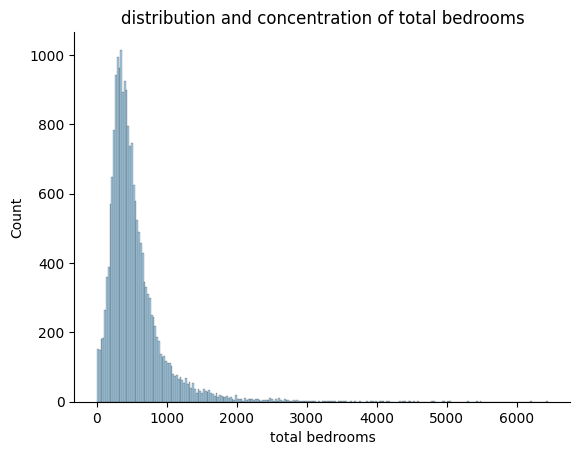

In [11]:
from IPython.core.display import display_pdf
# distribution and concentration of total bedrooms
sns.histplot(data = df,x ='total_bedrooms')
plt.title('distribution and concentration of total bedrooms')
plt.xlabel('total bedrooms')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

In [12]:
# imputing missing values in total_bedrooms with median value
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


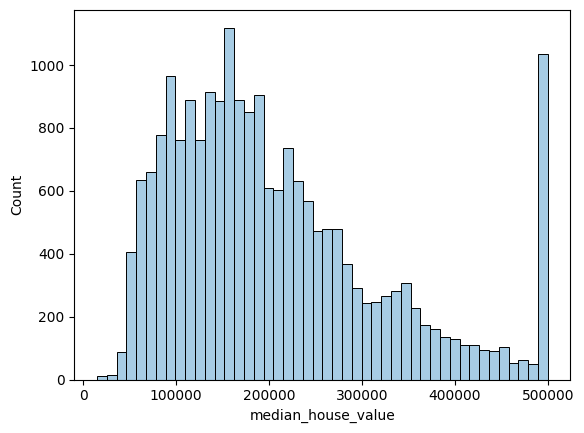

In [17]:
# how are house values distributed
sns.histplot(data=df, x ='median_house_value')
plt.show()

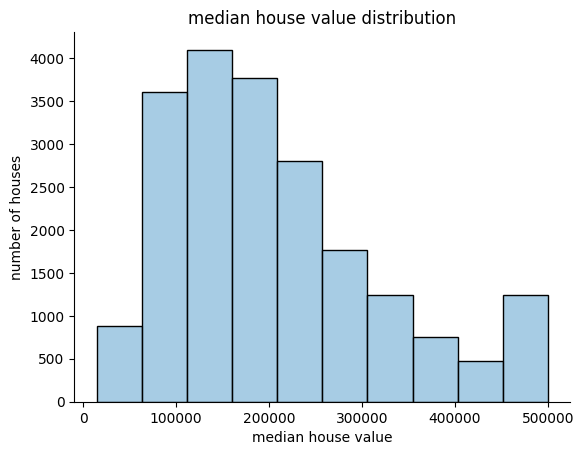

In [19]:
sns.histplot(data = df,x = 'median_house_value',binwidth =50000)
plt.title('median house value distribution')
plt.xlabel('median house value')
plt.ylabel('number of houses')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

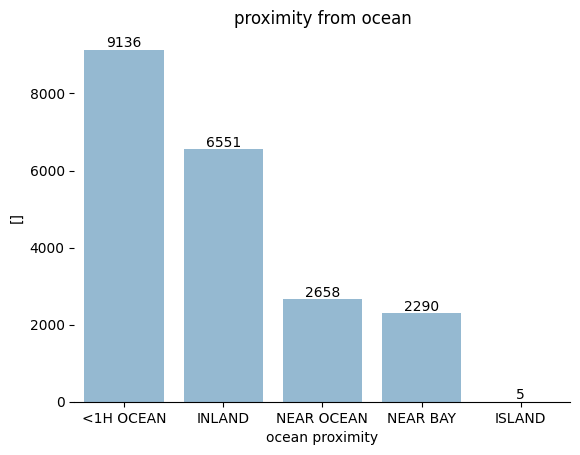

In [22]:
# how many housing blocks fall into each ocean_proximity category?
fig = sns.countplot(data = df,x = 'ocean_proximity',order =df ['ocean_proximity'].value_counts().index)
for p in fig.patches:
 plt.text(p.get_x()+ p.get_width()/ 2, p.get_height(),f'{int(p.get_height())}', ha='center' ,va='bottom')
plt.title('proximity from ocean')
plt.xlabel('ocean proximity')
plt.ylabel([])
plt.gca().spines[['top','left','right']].set_visible(False)
plt.show()

In [25]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


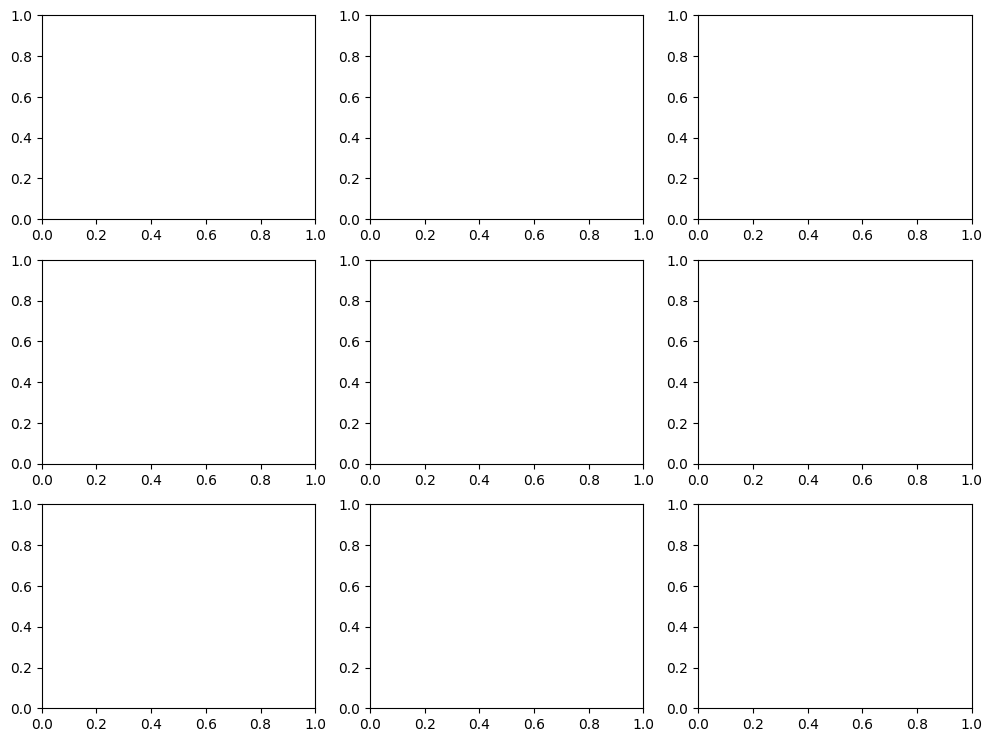

In [26]:
fig,axs = plt.subplots(nrows = 3,ncols = 3, figsize=(12,9))
plt.show()

In [42]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

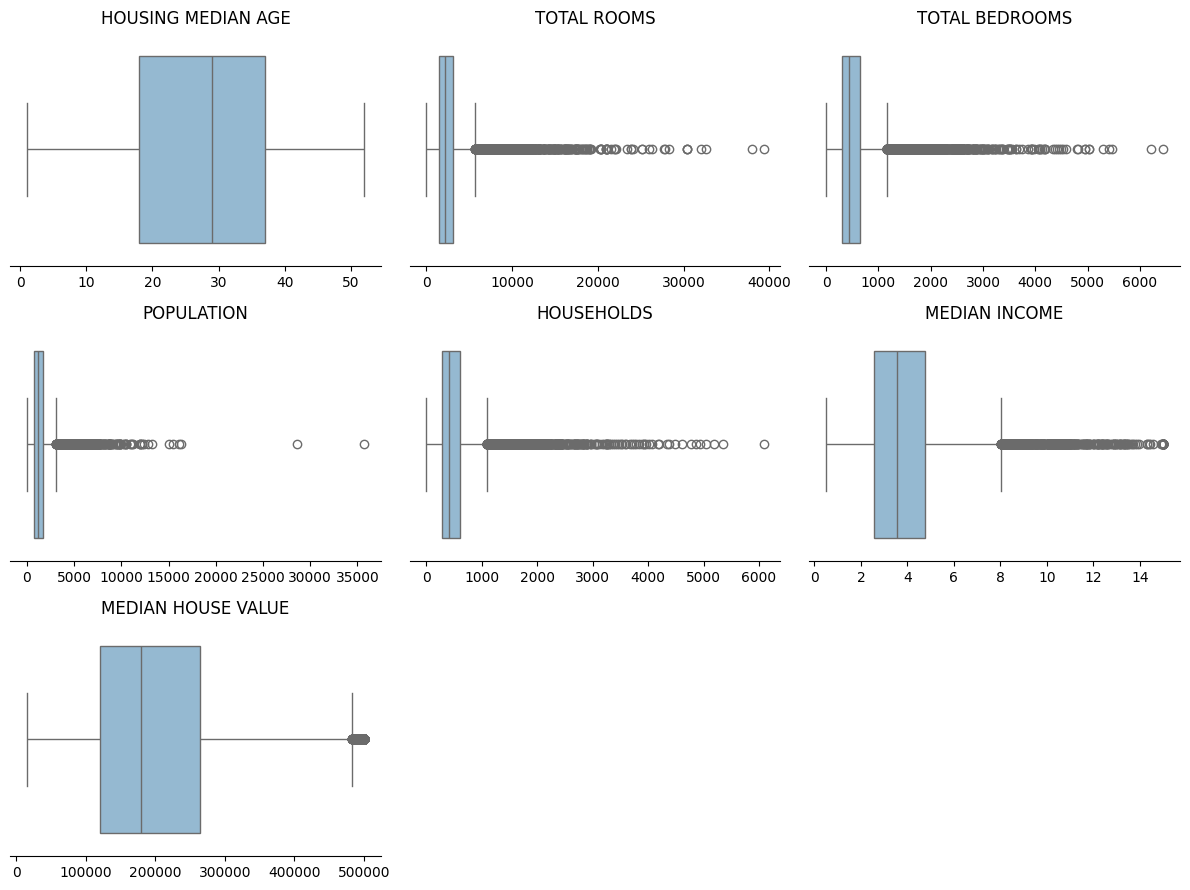

In [46]:
fig, axs = plt.subplots(nrows = 3,ncols=3,figsize =(12,9))

sns.boxplot(data = df, x = 'housing_median_age',ax =axs[0][0])
axs[0][0].set_title('HOUSING MEDIAN AGE')
axs[0][0].set_xlabel('')
axs[0][0].set_ylabel('')
axs[0][0].set_yticks([])
axs[0][0].spines[['top','left','right']].set_visible(False)

sns.boxplot(data = df, x = 'total_rooms',ax =axs[0][1])
axs[0][1].set_title('TOTAL ROOMS')
axs[0][1].set_xlabel('')
axs[0][1].set_ylabel('')
axs[0][1].set_yticks([])
axs[0][1].spines[['top','left','right']].set_visible(False)


sns.boxplot(data = df, x = 'total_bedrooms',ax =axs[0][2])
axs[0][2].set_title('TOTAL BEDROOMS')
axs[0][2].set_xlabel('')
axs[0][2].set_ylabel('')
axs[0][2].set_yticks([])
axs[0][2].spines[['top','left','right']].set_visible(False)

sns.boxplot(data = df, x = 'population',ax =axs[1][0])
axs[1][0].set_title('POPULATION')
axs[1][0].set_xlabel('')
axs[1][0].set_ylabel('')
axs[1][0].set_yticks([])
axs[1][0].spines[['top','left','right']].set_visible(False)

sns.boxplot(data = df, x = 'households',ax =axs[1][1])
axs[1][1].set_title('HOUSEHOLDS')
axs[1][1].set_xlabel('')
axs[1][1].set_ylabel('')
axs[1][1].set_yticks([])
axs[1][1].spines[['top','left','right']].set_visible(False)

sns.boxplot(data = df, x = 'median_income',ax =axs[1][2])
axs[1][2].set_title('MEDIAN INCOME')
axs[1][2].set_xlabel('')
axs[1][2].set_ylabel('')
axs[1][2].set_yticks([])
axs[1][2].spines[['top','left','right']].set_visible(False)

sns.boxplot(data = df, x = 'median_house_value',ax =axs[2][0])
axs[2][0].set_title('MEDIAN HOUSE VALUE')
axs[2][0].set_xlabel('')
axs[2][0].set_ylabel('')
axs[2][0].set_yticks([])
axs[2][0].spines[['top','left','right']].set_visible(False)

axs[2][1].set_visible(False)
axs[2][2].set_visible(False)

plt.tight_layout()
plt.show()

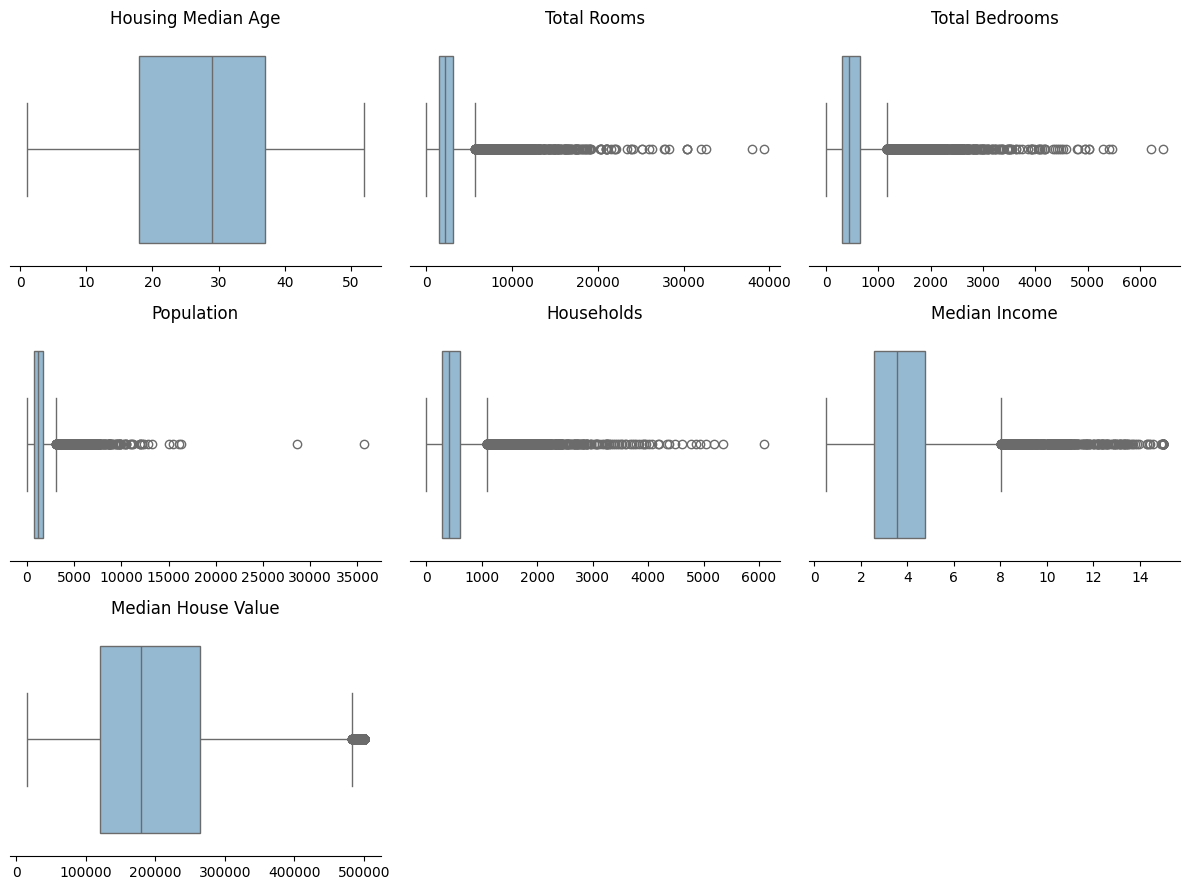

In [58]:
# through for loops
# outlier detection using boxplot
cols = ['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']

fig, axs = plt.subplots(nrows = 3,ncols = 3,figsize =(12,9))
axs = axs.flatten()

# iterating using for loop
for i,col in enumerate(cols):
  sns.boxplot(data = df,x = col, ax = axs[i])
  axs[i].set_title(col.replace('_',' ').title())
  axs[i].set_xlabel('')
  axs[i].set_ylabel('')
  axs[i].set_yticks([])
  axs[i].spines[['top','left','right']].set_visible(False)

for j in range(len(cols),len(axs)):
  axs[j].set_visible(False)


plt.tight_layout()
plt.show()

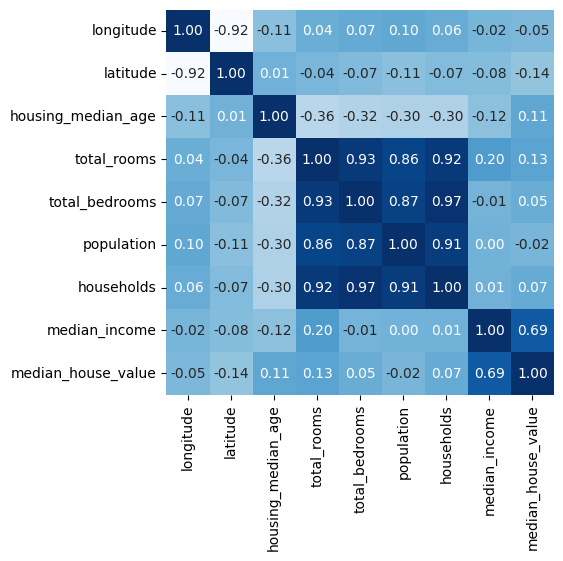

In [62]:
# correlation
plt.figure(figsize = (5,5))
sns.heatmap(df.drop('ocean_proximity',axis = 1).corr(),annot=True,fmt ='.2f',cmap ='Blues',cbar= False)
plt.show()

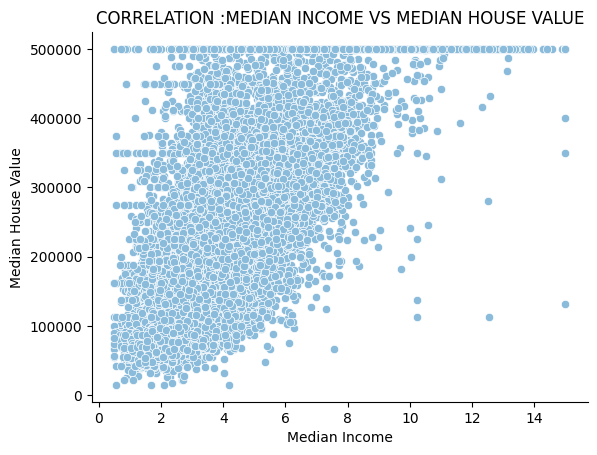

In [64]:
# correlation between median_hous_value and median_income
sns.scatterplot(data = df, x ='median_income',y = 'median_house_value')
plt.title('CORRELATION :MEDIAN INCOME VS MEDIAN HOUSE VALUE')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

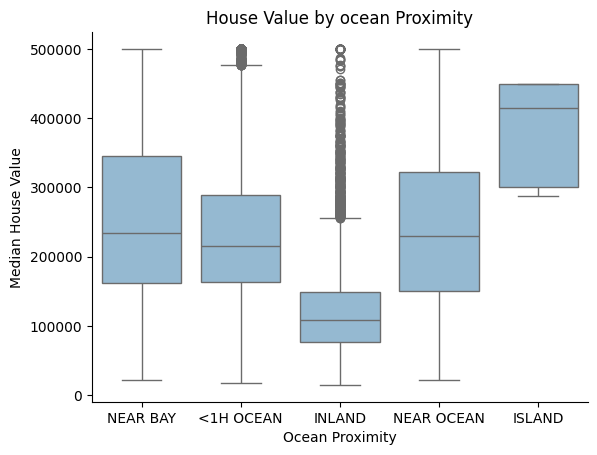

In [67]:
# how does ocean proximity influence house value
sns.boxplot(data = df,x ='ocean_proximity',y ='median_house_value')
plt.title('House Value by ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

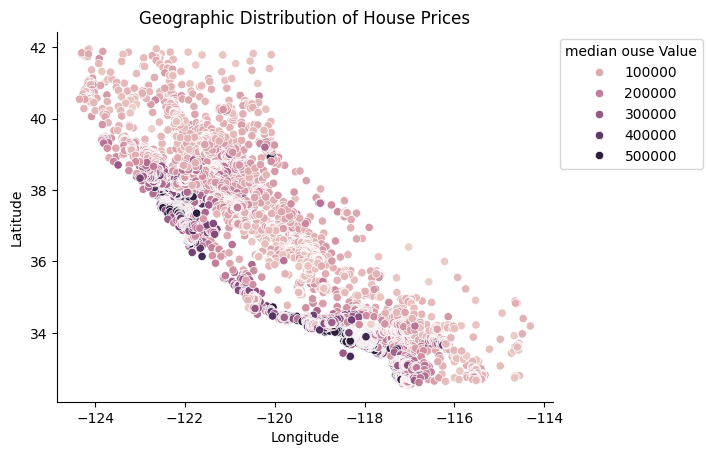

In [69]:
# geospatial distribution
# house pricing distribution by gps
sns.scatterplot(data = df,x ='longitude' , y ='latitude',hue = 'median_house_value')
plt.title('Geographic Distribution of House Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title = 'median ouse Value',bbox_to_anchor =(1,1),loc = 'upper left')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

In [76]:
# feature engineering
df['rooms_per_household'] = df['total_rooms']/ df['households']
df['bedrooms_per_room'] = df['total_bedrooms']/df['total_rooms']
df['population_per_household'] = df['population']/df['households']
df['income_per_household'] = df['median_income'] /df ['households']
df['bedrooms_per_room'] = df ['total_bedrooms']/df ['population']

df['regions'] = pd.cut(df['latitude'], bins = [32,34,36,38,40,42],
                       labels = ['South','Lower Central','Central','Upper Central','North'])
df['population_per_household_bins'] = pd.cut(df['population_per_household'],bins = [0,2,4,6,np.inf],
                                             labels=['<2','2 - 4','4 - 6','6+'])


In [78]:
# inspecting first few rowss after feature engineering
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,income_per_household,regions,population_per_household_bins
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.400621,2.555556,0.066073,Central,2 - 4
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.460641,2.109842,0.007295,Central,2 - 4
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.383065,2.802260,0.041002,Central,2 - 4
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.421147,2.547945,0.025768,Central,2 - 4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.495575,2.181467,0.014850,Central,2 - 4
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,4.761658,0.515738,2.139896,0.020916,Central,2 - 4
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,4.931907,0.446984,2.128405,0.007119,Central,2 - 4
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,4.797527,0.593777,1.788253,0.004822,Central,<2
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,4.294118,0.551410,2.026891,0.003496,Central,2 - 4
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,4.970588,0.455835,2.172269,0.005170,Central,2 - 4


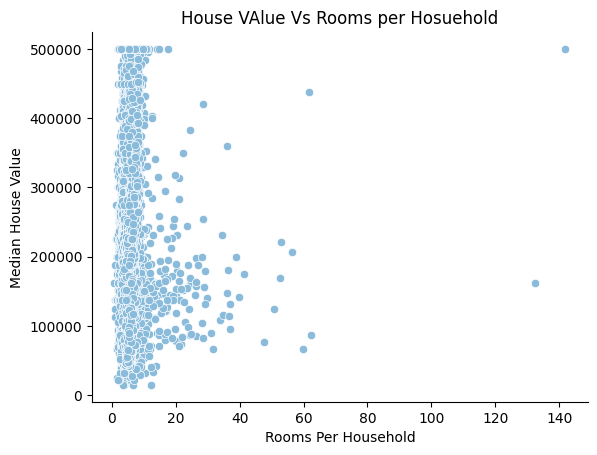

In [81]:
# realtion between average number of rooms per household and house value
sns.scatterplot(data =df,x='rooms_per_household', y = 'median_house_value')
plt.title('House VAlue Vs Rooms per Hosuehold')
plt.xlabel('Rooms Per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

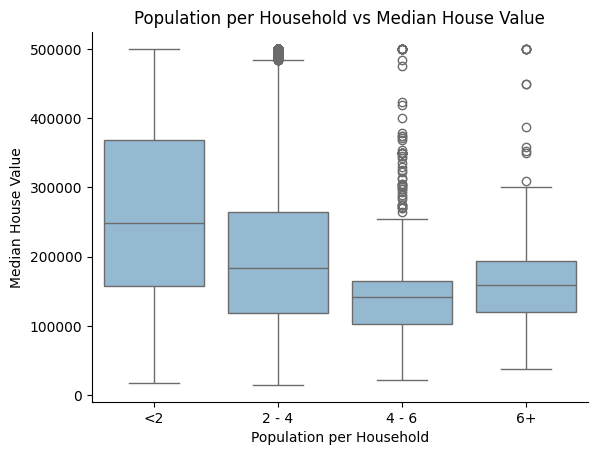

In [84]:
# average number of people per hosuhold vs median house value
sns.boxplot(data = df,x = 'population_per_household_bins',y = 'median_house_value')
plt.title('Population per Household vs Median House Value')
plt.xlabel('Population per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)


plt.show()

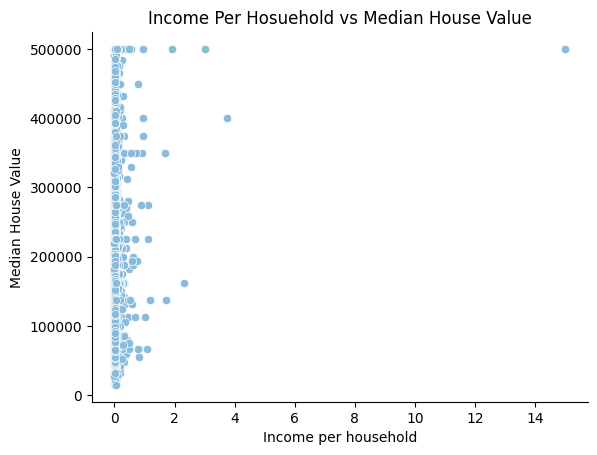

In [88]:
# income per houshold vs median house value
sns.scatterplot(data = df, x = 'income_per_household',y = 'median_house_value')
plt.title('Income Per Hosuehold vs Median House Value')
plt.xlabel('Income per household')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

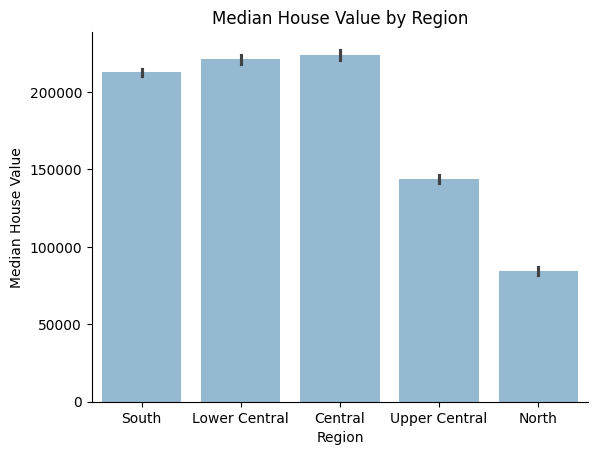

In [90]:
# median house value across regions
sns.barplot(data = df,x = 'regions',y = 'median_house_value')
plt.title('Median House Value by Region')
plt.xlabel('Region')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)

plt.show()
